# Linear Regression

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from src.linear_regression import LinearRegression
from src.Metrics import r2, mean_squared_error

np.random.seed(42)

Linear regression is a supervised learning algorithm used when the goal is to predict a continuous numerical value.
</br>
The model assumes that the target variable can be approximated by a linear combination of the input features: y_pred = intercept + coefficient * X

# Generating a synthetic dataset

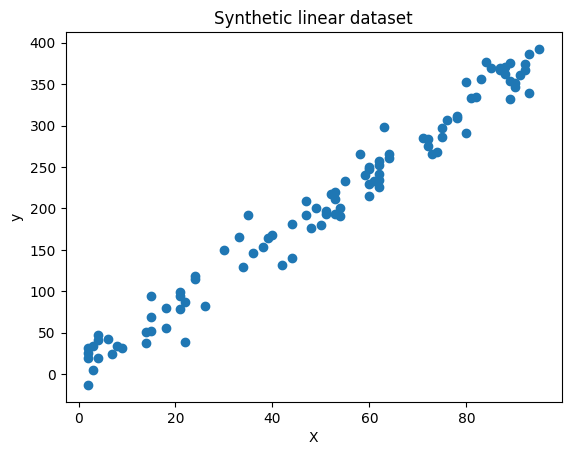

In [53]:
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))
noise = np.random.normal(0, 20, size=(n_sample, 1))

y = 4 * X + 3 + noise

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic linear dataset")
plt.show()

We generated a synthetic dataset using: y = 4x + 3 + noise . </br>
The noise is sampled from a normal distribution and centered at 0.

# Training

To make the computation easier, we rewrite the model in vectorized form. We store all input features in a matrix X and all coefficient in a vector θ.

The cost function measures how far the predictions are from the true values. In linear regression, training means finding the parameters θ that minimize a cost function. 
</br>
Here we will use the Mean Square Error (MSE) as our cost function.

θ is the vector of values used by the model, it contains the bias term θ₀ and the weights C to θₙ, which show how important each input value is in the prediction.
</br> So X θ is the dot product of the value vector and the associated weight vector.

## Training with the normal equation

The normal equation is a closed-form solution that directly gives the parameters θ minimizing the MSE for linear regression:

- $X\theta \approx y$
- $X^T X\theta = X^T y$
- $\left(X^T X\right)^{-1} \left(X^T X\right)\theta = \left(X^T X\right)^{-1} X^T y$
- $\theta = \left(X^T X\right)^{-1} X^T y$

In [54]:
X_b = np.c_[np.ones((n_sample, 1)), X] # Adding intercept (θ₀ = 1)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.66820285],
       [3.95401579]])

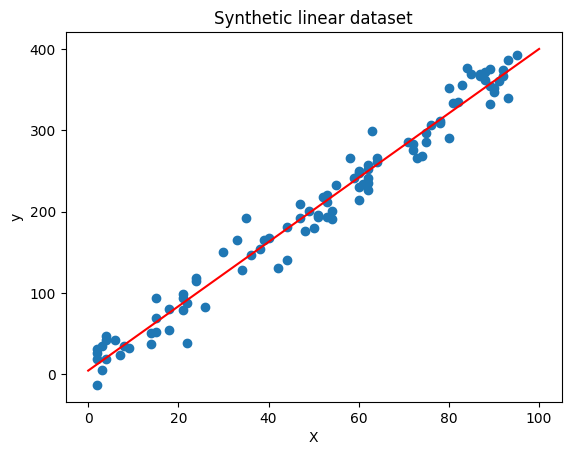

In [55]:
# Test
X_new = np.array([[0], [100]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b @ theta_best
y_predict

plt.plot(X_new, y_predict, "r-")
plt.scatter(X, y,)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic linear dataset")
plt.show()

We have a pretty good fit here ! </br>
Note that the normal equation works for any model that is linear in θ, but it can work for one that is non linear in x such as y = θ₀ + θ₁x + θ₂ sin(x)

Now that the model has been trained, we can evaluate its performance on the training data.

In [56]:
y_train_predict = X_b @ theta_best

mse_normal = np.mean((y - y_train_predict) ** 2)
rmse_normal = np.sqrt(mse_normal) # RMSE is easier to interpret because it is expressed is the same unit as the target.

mse_normal, rmse_normal

(np.float64(361.5602380139437), np.float64(19.014737390086243))

## Training with the gradient descent

The idea is to tweak the parameters iteratively in order to minimize a cost function. <br>
We start with by giving a random value to θ (random initialization) and for every step we take, we try to minimize the loss function, until the algorithm converges to a minimum.

"Fortunately, the MSE cost function for a Linear Regression model happens to be a convex function" Aurelien Geron, Hands on ML

We can compute the gradient for a batch using the formula below:

![description](../images/gradient_vector_of_cost_function.png)

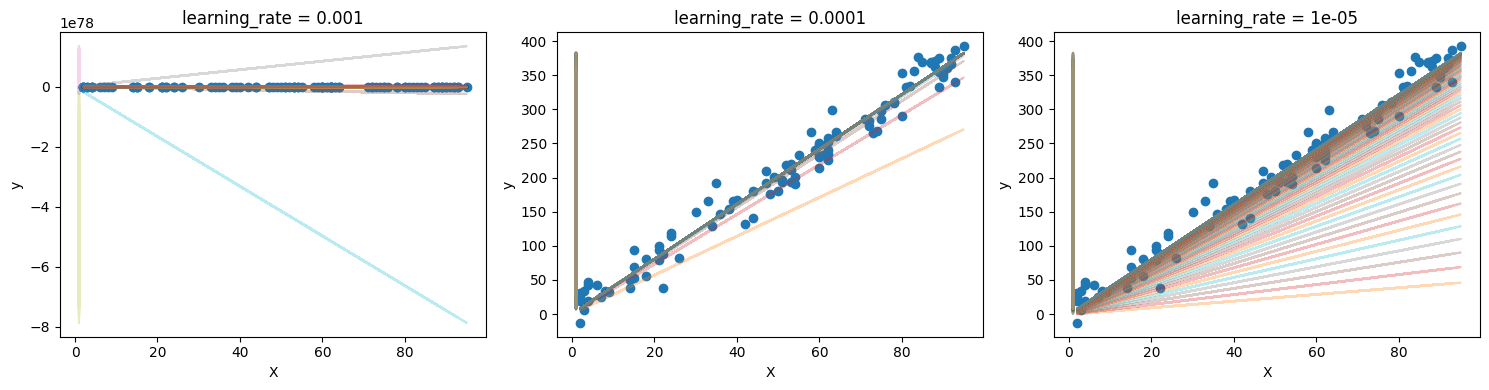

In [57]:
X_b = np.c_[np.ones((n_sample, 1)), X] # Adding intercept (θ₀ = 1)

# We try with 3 different learning rates

learning_rates = [0.001, 0.0001, 0.00001]
n_iterations = 100
m = len(X)
cost_history = []

fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

for ax, learning_rate in zip(axes, learning_rates):
    theta = np.random.randn(2, 1) # random initialization

    ax.scatter(X, y)

    for iteration in range(n_iterations):
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - gradients * learning_rate

        y_predict = X_b @ theta
        
        ax.plot(X_b, y_predict, alpha=0.3)

        # We will use it later to compare with the normal equation
        if learning_rate == 0.00001: 
            mse = mean_squared_error(y, y_predict)
            cost_history.append(mse)

    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.set_title(f"learning_rate = {learning_rate}")
    

plt.tight_layout()
plt.show()



This is a good visualization of the impact of the learning rate on the training of our model. We can see that on the left that the learning rate is too high and the algorithm jumps all over the place. On the right the algorithm converges but it takes a long time while in the middle it only takes a few step.

To you find a good learning rate, you can do a grid search, just limit the number of iterations beforehand. </br> 
To find a good number of iterations, you can start with a very large number and stop the algorithm when the gradient becomes very tiny. 

Let's compare the results of the normal equation and the gradient descent:

Normal equation RMSE: 19.014737390086243, Gradient descent RMSE: 19.194481410347915


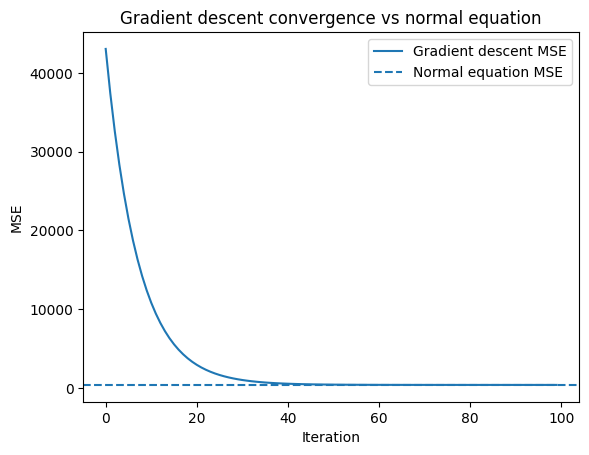

In [58]:
mse_gd = mean_squared_error(y, y_predict)
rmse_gd = np.sqrt(mse_gd)
print(f'Normal equation RMSE: {rmse_normal}, Gradient descent RMSE: {rmse_gd}')


plt.plot(cost_history, label="Gradient descent MSE")
plt.axhline(y=mse_normal, linestyle="--", label="Normal equation MSE")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient descent convergence vs normal equation")
plt.legend()
plt.show()

For visualization purposes I chose the smallest learning rate out of the three we tested. </br>
With a higher learning rate, gradient descent can converge so quickly that most of the decrease happens in the first few iterations

# Trying the library

To make it easier to experiment with different parameters and hyper-parameters we will use the functions defined in the .py file

In [59]:
X = np.random.randint(1, 100, size=100)
y = 4 * X

ne_model = LinearRegression(solver='ne').fit(X, y)
bgd_model = LinearRegression(solver='bgd', learning_rate=0.00001, n_iterations=100).fit(X, y)
sgd_model = LinearRegression(solver='sgd', learning_rate=0.00001, n_iterations=100).fit(X, y)

print(ne_model.theta)
print(bgd_model.theta)
print(sgd_model.theta)

[[7.10542736e-14]
 [4.00000000e+00]]
[[-1.74750727]
 [ 4.02292911]]
[[-1.40715354]
 [ 4.02067146]]


In [60]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

X_test = np.array([6, 7, 8])

mod = LinearRegression(solver='bgd', learning_rate=0.001, n_iterations=100000).fit(X, y)

print(mod.predict(X_test))

[[13.]
 [15.]
 [17.]]


# Hypotheses of the linear regression

There are assumptions behind a linear regression model that need to be satisfied for it to be an appropriate and reliable tool.

## - Linearity

Hence the name, linear regression assumes that the relationship between the independant variable and the dependant variables is linear. </br> As we can see below the model just does not fit the data when y != X θ + noise.

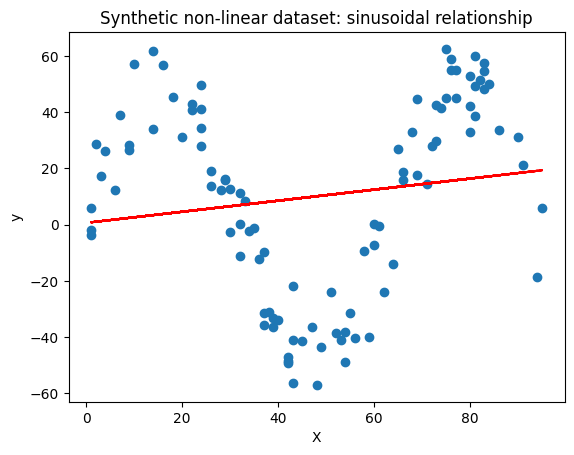

In [61]:
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))
noise = np.random.normal(0, 10, size=(n_sample, 1))

y = 50 * np.sin(X/10) + noise

y_predict = LinearRegression(solver='bgd', learning_rate=0.00001, n_iterations=100).fit(X, y).predict(X=X).reshape(-1,1)

plt.plot(X, y_predict, "r-")
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic non-linear dataset: sinusoidal relationship")
plt.show()

## - Independance of erros

Here below, the model seems to fit the data because the relationship bewteen X and y is linear. 
</br>
The problem is that each error is supposed to bring additional information because they are independants.</br> In this example, the errors are dependants because they partly depend on the previous one. As a result the model treats the data as if it contained more information than it really contains.

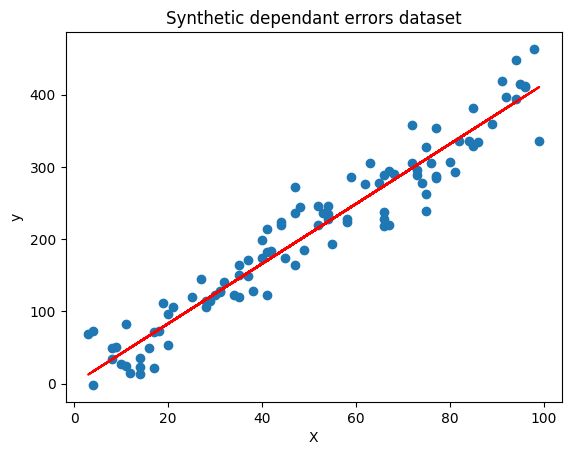

In [62]:
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))

errors = np.zeros((n_sample, 1))
for i in range(1, n_sample):
    errors[i] = errors[i-1] * 0.8 + np.random.normal(0, 20)

dep_y = 4 * X + 3 + errors

dep_y_predict = LinearRegression(solver='bgd', learning_rate=0.00001, n_iterations=100).fit(X, dep_y).predict(X=X) #.reshape(-1,1)

plt.plot(X, dep_y_predict, "r-")
plt.scatter(X, dep_y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic dependant errors dataset")
plt.show()


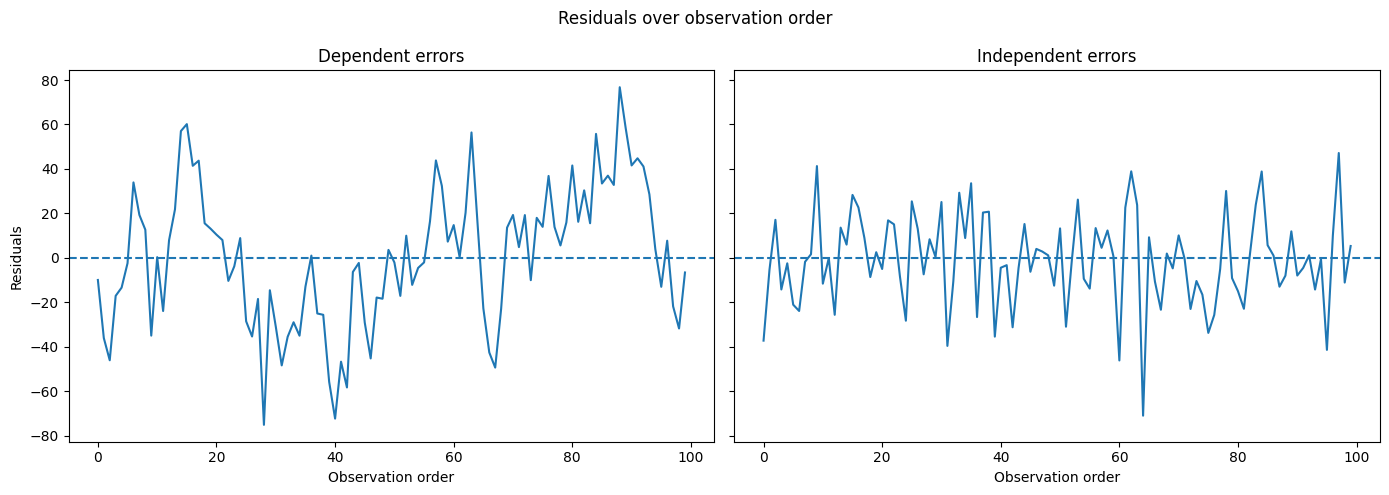

In [63]:
# Dependant errors
dep_residuals = dep_y - dep_y_predict

# Independant errors
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))
noise = np.random.normal(0, 20, size=(n_sample, 1))

ind_y = 4 * X + 3 + noise

model = LinearRegression(solver='bgd', learning_rate=0.00001, n_iterations=100)

ind_y_predict = model.fit(X, ind_y).predict(X)

ind_residuals = ind_y - ind_y_predict

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(dep_residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Observation order")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Dependent errors")

axes[1].plot(ind_residuals)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Observation order")
axes[1].set_title("Independent errors")

plt.suptitle("Residuals over observation order")
plt.tight_layout()
plt.show()

The two graphs display the distribution of errors over the observation order. 
</br> 
We can see that dependent errors create visible patterns, while independent errors are randomly scattered around 0.
</br> This is a simple way to spot whether the error independence assumption is respected.

## - Homoscedasticity

Homoscedasticity means that the errors have a constant variance across all predicted values.
</br>
When this assumption is not met, the model suffers from heteroscedasticity, in the graph below, this means that the model predictions become less precise for higher values of X.

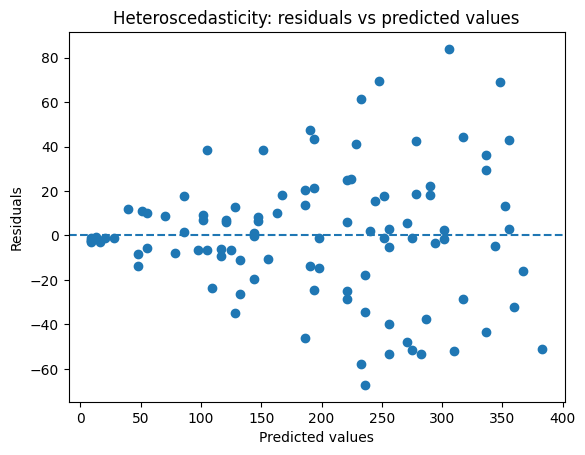

In [64]:
n_sample = 100

X = np.random.randint(1, 100, size=(n_sample, 1))

noise = np.random.normal(0, X * 0.5, size=(n_sample, 1))

y = 4 * X + 3 + noise

model = LinearRegression(solver="ne")
y_predict = model.fit(X, y).predict(X)

residuals = y - y_predict

plt.scatter(y_predict, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Heteroscedasticity: residuals vs predicted values")
plt.show()

## - Normality of errors

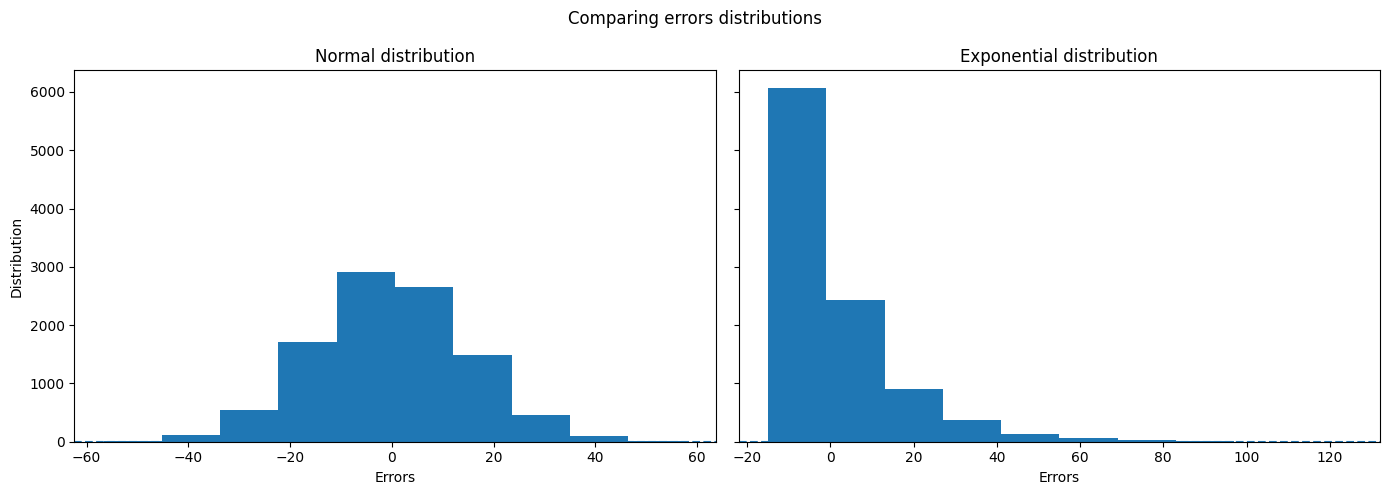

In [69]:
n_sample = 10000

X = np.random.randint(1, 100, size=(n_sample, 1))

normal_errors = np.random.normal(loc=0, scale=15, size=10000).reshape(-1, 1)
normal_y = 4 * X + normal_errors 

exp_errors = (np.random.exponential(scale=15, size=10000) - 15).reshape(-1, 1)
exp_y = 4 * X + exp_errors

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(normal_errors)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Errors")
axes[0].set_ylabel("Distribution")
axes[0].set_title("Normal distribution")

axes[1].hist(exp_errors)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Errors")
axes[1].set_title("Exponential distribution")

plt.suptitle("Comparing errors distributions")
plt.tight_layout()
plt.show()

Now that we have generated two datasets with different error distributions, we can fit the same linear regression model on both of them.
</br>
This allows us to see whether changing the shape of the errors affects the fitted regression line and the way observations are spread around it.

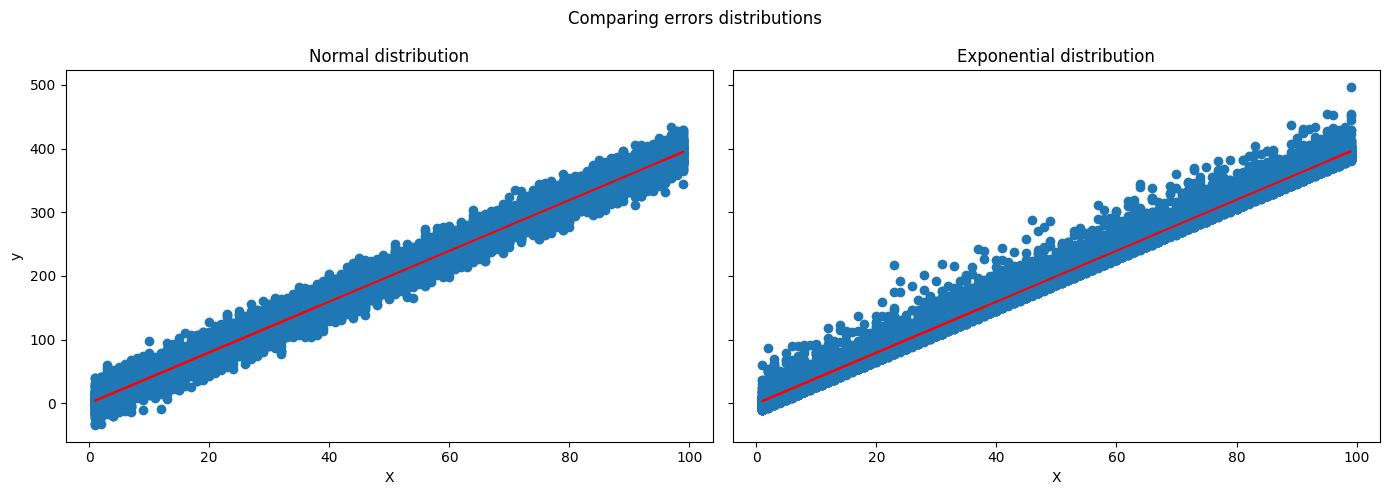

In [70]:
normal_predict = LinearRegression(solver='bgd', learning_rate=0.0000001, n_iterations=10000).fit(X, normal_y).predict(X=X)

exponential_predict = LinearRegression(solver='bgd', learning_rate=0.0000001, n_iterations=10000).fit(X, exp_y).predict(X=X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(X, normal_predict, "r-")
axes[0].scatter(X, normal_y)
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].set_title("Normal distribution")

axes[1].plot(X, exponential_predict, "r-")
axes[1].scatter(X, exp_y)
axes[1].set_xlabel("X")
axes[1].set_title("Exponential distribution")

plt.suptitle("Comparing errors distributions")
plt.tight_layout()
plt.show()

Normal errors are more symmetric around the line, while exponential errors create an asymmetric pattern with more large positive errors.
</br>
Even if the regression still captures the general trend, non-normal errors can make statistical interpretation less reliable.